# Notebook to get an overview of the Data

In [4]:
# Imports
import os
import pandas as pd
import matplotlib.pyplot as plt
import h3

In [5]:
# Make sure that everyone has same dataset. Has to be in gitignore because toooo large
df = pd.read_csv('../data/Taxi_Trips_(2024-)_20260511.csv') 

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20552\612969188.py:2: DtypeWarning: Columns (0: Trip Miles) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/Taxi_Trips_(2024-)_20260511.csv')


In [ ]:
df.head()

,Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,...,Extras,Trip Total,Payment Type,Company,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
0,baecce6901ab1ef6ffeaae590b41fbfa4aa3faaa,ca83178fa4ea3bcd66fe18442103abfb68222d7a440868...,05/01/2026 12:00:00 AM,05/01/2026 12:15:00 AM,"1,261",11.82,NaN,NaN,42.0,7.0,...,$0.00,$30.75,Prcard,Flash Cab,41.778877,-87.594925,POINT (-87.5949254391 41.7788768603),41.922686,-87.649489,POINT (-87.6494887289 41.9226862843)
1,e96d8e910cc577d191447dfdf5dc59a6a5ddc9f5,0c758d798a3980ff73e5f1a334db48be8aa4271db5d6cf...,05/01/2026 12:00:00 AM,05/01/2026 12:00:00 AM,36,0.18,NaN,NaN,56.0,56.0,...,$0.00,$3.50,Cash,Sun Taxi,41.792592,-87.769615,POINT (-87.7696154528 41.7925923603),41.792592,-87.769615,POINT (-87.7696154528 41.7925923603)
2,954c3b4006793e96c39ea56df7db1cf4283aede9,b5ad9d970e0745256fbb7517babae43abcb43115d076df...,05/01/2026 12:00:00 AM,05/01/2026 12:30:00 AM,"1,980",13.9,NaN,NaN,56.0,8.0,...,$4.00,$41.50,Cash,Transit Administrative Center Inc,41.792592,-87.769615,POINT (-87.7696154528 41.7925923603),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
3,2e96dbb28bb463f8bc6151f00aeecbee8bcd4706,34766262f2e312774b1ad4651b99dc23b780dbd00b658f...,05/01/2026 12:00:00 AM,05/01/2026 12:15:00 AM,"1,269",13.04,NaN,NaN,56.0,39.0,...,$5.00,$46.20,Credit Card,Taxicab Insurance Agency Llc,41.792592,-87.769615,POINT (-87.7696154528 41.7925923603),41.808916,-87.596183,POINT (-87.5961833442 41.8089162826)
4,615a5749db72b8094af8fd1ff8409fe65c364e2d,617d878f0486c82431cd73a6c1cee0992947dea1140244...,05/01/2026 12:00:00 AM,05/01/2026 12:30:00 AM,"1,920",14.1,NaN,NaN,56.0,NaN,...,$22.00,$58.00,Credit Card,Transit Administrative Center Inc,41.792592,-87.769615,POINT (-87.7696154528 41.7925923603),NaN,NaN,NaN


In [ ]:
df.shape

(4610021, 23)

In [ ]:
df['Trip Start Timestamp'] = pd.to_datetime(df['Trip Start Timestamp'])
df['Trip End Timestamp'] = pd.to_datetime(df['Trip End Timestamp'])
df['Trip End Timestamp'].min()

Timestamp('2025-08-22 07:45:00')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4610021 entries, 0 to 4610020
Data columns (total 23 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   Trip ID                     str           
 1   Taxi ID                     str           
 2   Trip Start Timestamp        datetime64[us]
 3   Trip End Timestamp          datetime64[us]
 4   Trip Seconds                str           
 5   Trip Miles                  object        
 6   Pickup Census Tract         float64       
 7   Dropoff Census Tract        float64       
 8   Pickup Community Area       float64       
 9   Dropoff Community Area      float64       
 10  Fare                        str           
 11  Tips                        str           
 12  Tolls                       str           
 13  Extras                      str           
 14  Trip Total                  str           
 15  Payment Type                str           
 16  Company                     s

In [ ]:
# Unique area, latitude and longitude
pickup_df = df[['Pickup Centroid Latitude', 'Pickup Centroid Longitude','Pickup Community Area']].drop_duplicates()
grouped = pickup_df.groupby('Pickup Community Area').size()
grouped[grouped > 1]

Pickup Community Area
1.0     13
2.0     14
3.0     12
4.0     11
5.0      9
        ..
72.0     4
73.0     5
75.0     4
76.0     6
77.0    18
Length: 67, dtype: int64

In [17]:
pickup_df[pickup_df['Pickup Community Area'] == 13]

,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Community Area
621,41.983636,-87.723583,13.0
41062,41.980844,-87.736084,13.0
373520,41.986558,-87.713369,13.0
502394,41.978294,-87.716430,13.0
1047481,41.990064,-87.723968,13.0


Discretize 

In [8]:
# Drop rows with no location
df = df.dropna(subset=["Pickup Centroid Latitude", "Pickup Centroid Longitude"])

# Parse timestamp
df["pickup_dt"] = pd.to_datetime(df["Trip Start Timestamp"])
df["dropoff_dt"] = pd.to_datetime(df["Trip End Timestamp"])

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20552\963605738.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["pickup_dt"] = pd.to_datetime(df["Trip Start Timestamp"])
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20552\963605738.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["dropoff_dt"] = pd.to_datetime(df["Trip End Timestamp"])


In [10]:
def to_h3(lat, lng, res):
    try:
        return h3.latlng_to_cell(lat, lng, res)
    except Exception:
        return None

for res in [7, 8, 9]:
    df[f"h3_r{res}"] = df.apply(
        lambda r: to_h3(r["Pickup Centroid Latitude"],
                        r["Pickup Centroid Longitude"], res), axis=1
    )

MemoryError: Unable to allocate 68.4 MiB for an array with shape (4483016,) and data type complex128

In [ ]:
df["pickup_bucket_1h"]  = df["pickup_dt"].dt.floor("H")           # hourly
df["pickup_bucket_4h"]  = df["pickup_dt"].dt.floor("4H")          # 4-hourly
df["pickup_bucket_day"] = df["pickup_dt"].dt.floor("D")            # daily

# Useful extra features for your ML model
df["pickup_hour"]       = df["pickup_dt"].dt.hour
df["pickup_dayofweek"]  = df["pickup_dt"].dt.dayofweek             # 0=Mon, 6=Sun
df["pickup_is_weekend"] = df["pickup_dayofweek"].isin([5, 6]).astype(int)

In [ ]:
def make_demand(df, spatial_col, time_col):
    return (
        df.groupby([spatial_col, time_col])
          .size()
          .reset_index(name="trip_count")
    )

# H3 at different resolutions
demand_r7_1h  = make_demand(df, "h3_r7", "bucket_1h")
demand_r8_1h  = make_demand(df, "h3_r8", "bucket_1h")
demand_r8_4h  = make_demand(df, "h3_r8", "bucket_4h")

# Census tract version (for the Task 3 comparison)
demand_tract  = make_demand(df, "pickup_census_tract", "bucket_1h")

print(demand_r8_1h.head())
#          h3_r8           bucket_1h  trip_count
# 882a100d2bfffff  2024-01-01 08:00          47

ModuleNotFoundError: No module named 'geopandas'

In [ ]:
df.isnull().sum()/len(df)

Trip ID                       0.000000
Taxi ID                       0.000003
Trip Start Timestamp          0.000001
Trip End Timestamp            0.000054
Trip Seconds                  0.000194
Trip Miles                    0.000010
Pickup Census Tract           0.536529
Dropoff Census Tract          0.548488
Pickup Community Area         0.028013
Dropoff Community Area        0.081473
Fare                          0.001263
Tips                          0.001263
Tolls                         0.001263
Extras                        0.001263
Trip Total                    0.001263
Payment Type                  0.000001
Company                       0.000001
Pickup Centroid Latitude      0.027550
Pickup Centroid Longitude     0.027550
Pickup Centroid Location      0.027550
Dropoff Centroid Latitude     0.077253
Dropoff Centroid Longitude    0.077253
Dropoff Centroid  Location    0.077253
dtype: float64

In [22]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_percent"] = (missing["missing_count"] / len(df) * 100).round(2)
missing.sort_values("missing_percent", ascending=False)

,missing_count,missing_percent
Dropoff Census Tract,8435004,56.98
Pickup Census Tract,8237431,55.65
Dropoff Community Area,1320108,8.92
Dropoff Centroid Longitude,1241359,8.39
Dropoff Centroid Location,1241359,8.39
Dropoff Centroid Latitude,1241359,8.39
Pickup Community Area,413385,2.79
Pickup Centroid Location,405819,2.74
Pickup Centroid Latitude,405819,2.74
Pickup Centroid Longitude,405819,2.74


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["Trip ID"].duplicated().sum()

np.int64(0)

no duplicate trip ids, or rows

C:\Users\Georg\AppData\Local\Temp\ipykernel_724\3043268490.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Trip Start Timestamp"] = pd.to_datetime(df["Trip Start Timestamp"])


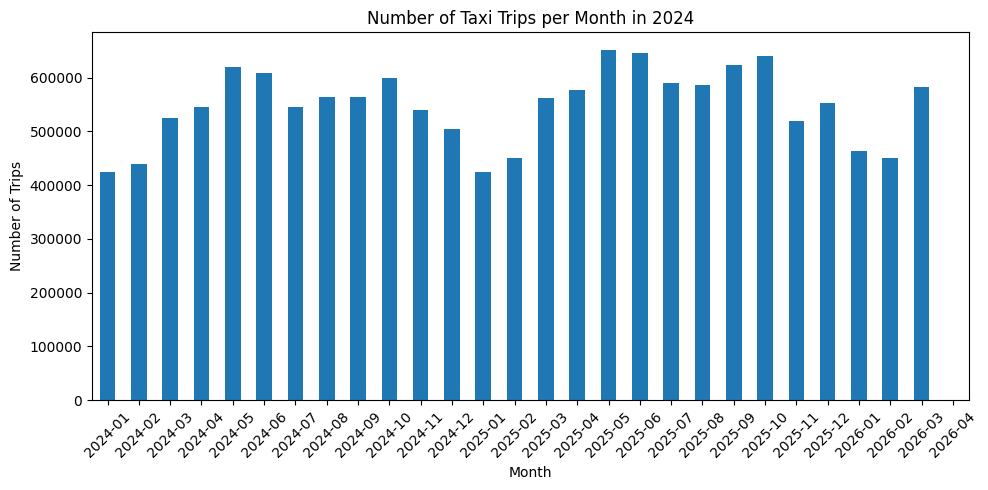

In [ ]:
df["Trip Start Timestamp"] = pd.to_datetime(df["Trip Start Timestamp"])

trips_per_month = (
    df["Trip Start Timestamp"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))
trips_per_month.plot(kind="bar")
plt.title("Number of Taxi Trips per Month")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
feature = "Extras"

df[feature].dropna().unique()[:10].tolist()

['$5,00',
 '$0,00',
 '$4,00',
 '$2,00',
 '$12,00',
 '$10,00',
 '$17,00',
 '$5,50',
 '$26,00',
 '$6,00']